## Step 1 – Data Preparation

* Load dataset (2022.csv).

* Clean numeric columns (replace commas with dots, convert to float).

* Drop irrelevant columns: Whisker-high, Whisker-low, Dystopia (1.83) + residual.

* Select features (Explained by: GDP per capita, Social support, Healthy life expectancy, Freedom, Generosity, Perceptions of corruption) as predictors X.

* Target = Happiness score.

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [209]:
df = pd.read_csv("Cleaned_2022.csv")
df.head()

,Unnamed: 0,RANK,Country,Happiness score,Whisker-high,Whisker-low,Dystopia (1.83) + residual,Explained by: GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,GDP_tier,Computed_Rank
0,0,1,Finland,7.821,7.886,7.756,2.518,1.892,1.258,0.775,0.736,0.109,0.534,High,1
1,1,2,Denmark,7.636,7.710,7.563,2.226,1.953,1.243,0.777,0.719,0.188,0.532,High,2
2,2,3,Iceland,7.557,7.651,7.464,2.320,1.936,1.320,0.803,0.718,0.270,0.191,High,3
3,3,4,Switzerland,7.512,7.586,7.437,2.153,2.026,1.226,0.822,0.677,0.147,0.461,High,4
4,4,5,Netherlands,7.415,7.471,7.359,2.137,1.945,1.206,0.787,0.651,0.271,0.419,High,5


In [210]:
df = df.drop('Unnamed: 0', axis = 1)

In [211]:
print("Shape of data:", df.shape)
df.head()

Shape of data: (146, 14)


,RANK,Country,Happiness score,Whisker-high,Whisker-low,Dystopia (1.83) + residual,Explained by: GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,GDP_tier,Computed_Rank
0,1,Finland,7.821,7.886,7.756,2.518,1.892,1.258,0.775,0.736,0.109,0.534,High,1
1,2,Denmark,7.636,7.710,7.563,2.226,1.953,1.243,0.777,0.719,0.188,0.532,High,2
2,3,Iceland,7.557,7.651,7.464,2.320,1.936,1.320,0.803,0.718,0.270,0.191,High,3
3,4,Switzerland,7.512,7.586,7.437,2.153,2.026,1.226,0.822,0.677,0.147,0.461,High,4
4,5,Netherlands,7.415,7.471,7.359,2.137,1.945,1.206,0.787,0.651,0.271,0.419,High,5


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 14 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   RANK                                        146 non-null    int64  
 1   Country                                     146 non-null    object 
 2   Happiness score                             146 non-null    float64
 3   Whisker-high                                146 non-null    float64
 4   Whisker-low                                 146 non-null    float64
 5   Dystopia (1.83) + residual                  146 non-null    float64
 6   Explained by: GDP per capita                146 non-null    float64
 7   Explained by: Social support                146 non-null    float64
 8   Explained by: Healthy life expectancy       146 non-null    float64
 9   Explained by: Freedom to make life choices  146 non-null    float64
 10  Explained by: 

In [213]:
X = df[["Explained by: GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"]]

y = df['Happiness score']

## Step 2 – Train/Test Split

In [215]:
from sklearn.model_selection import train_test_split

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Step 3 – Model 1: Linear Regression

* Train a Linear Regression model.

* Evaluate with R² and RMSE on test set.

In [218]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [219]:
model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train, y_train)


LinearRegression()

In [220]:
y_pred = model_lin_reg.predict(X_test)

In [221]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression R²:", round(r2, 3))
print("Linear Regression RMSE:", round(rmse, 2))

Linear Regression R²: 0.703
Linear Regression RMSE: 0.56


## Step 4 – Model 2: Random Forest Regressor

* Train a Random Forest Regressor.

* Compare its performance with Linear Regression.

In [223]:
from sklearn.ensemble import RandomForestRegressor

In [224]:
model_rf = RandomForestRegressor(n_estimators = 100, random_state = 42)

model_rf.fit(X_train, y_train)
    

RandomForestRegressor(random_state=42)

In [225]:
y_pred_rf = model_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R²:", round(r2_rf, 3))
print("Random Forest RMSE:", round(rmse_rf, 2))

Random Forest R²: 0.701
Random Forest RMSE: 0.56


## Step 5 – Model Comparison and Feature Importance

In [227]:

print("Linear Regression -> R²:", round(r2,3), " | RMSE:", round(rmse,2))
print("Random Forest     -> R²:", round(r2_rf,3), " | RMSE:", round(rmse_rf,2))


Linear Regression -> R²: 0.703  | RMSE: 0.56
Random Forest     -> R²: 0.701  | RMSE: 0.56


In [228]:

importances = model_rf.feature_importances_
feature_names = X.columns

feat_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_importance_df)


                                      Feature  Importance
0                Explained by: GDP per capita    0.477855
1                Explained by: Social support    0.205295
3  Explained by: Freedom to make life choices    0.122946
2       Explained by: Healthy life expectancy    0.114041
5     Explained by: Perceptions of corruption    0.048387
4                    Explained by: Generosity    0.031476


C:\Users\Admin\AppData\Local\Temp\ipykernel_13088\2262364124.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_importance_df, palette="viridis")


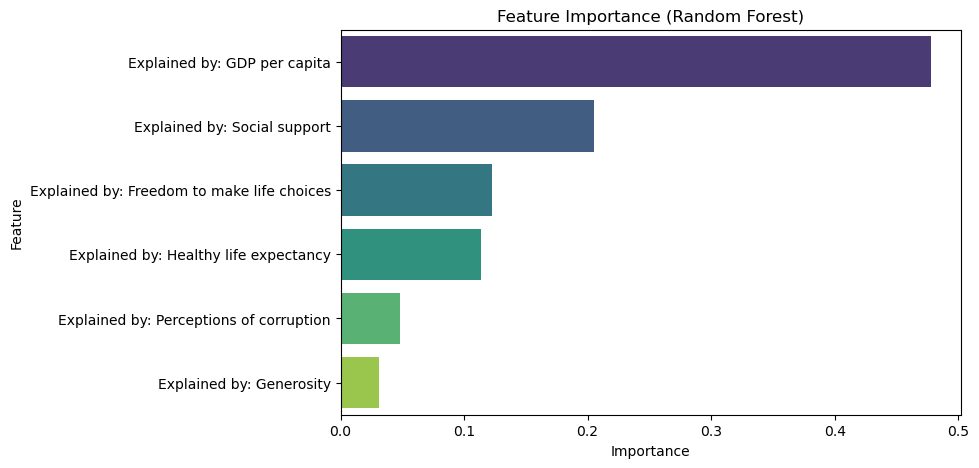

In [229]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_importance_df, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()